# 🍷 System rekomendacji win
## Porównanie modeli: NCF, XGBoost, Random Forest, RP3β

Ten notebook porównuje cztery podejścia do rekomendacji win:

| Model | Typ | Opis |
|---|---|---|
| **XGBoost Raw** | drzewo gradientowe | operuje wprost na ID użytkownika i wina |
| **Random Forest Raw** | las losowy | jak wyżej |
| **NCF** | sieć neuronowa | uczy się reprezentacji (embeddingów) użytkowników i win |
| **XGB / RF + NCF Emb** | hybryda | drzewa trenowane na embeddingach z NCF |
| **RP3β** | filtrowanie kolaboratywne | podobieństwo między winami przez losowy spacer po grafie |

### Metryki ewaluacji
- **RMSE / MAE / R²** – jak dobrze model przewiduje *wartość* oceny (regresja)
- **Precision@k** – ile z top-k rekomendacji ma ocenę ≥ 4.0
- **Recall@k** – ile z *wszystkich* dobrych win trafiło do top-k
- **NDCG@k** – ranking z gradowaną trafnością (lepsze wina wyżej = wyższy wynik)
- **Coverage** – jaki % katalogu win model w ogóle rekomenduje


## 1. Importy i konfiguracja

In [2]:
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import normalize
from sklearn.ensemble import RandomForestRegressor
from scipy.sparse import csr_matrix, diags
import xgboost as xgb
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")

# Używamy GPU jeśli dostępne, inaczej CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Biblioteki załadowane!")
print(f"Używamy: {device}")
print(f"PyTorch: {torch.__version__}")


Biblioteki załadowane!
Używamy: cuda
PyTorch: 2.10.0+cu126


## 2. Wczytanie danych i podział na zbiór treningowy / testowy

Dane sortujemy chronologicznie i dzielimy **80% train / 20% test**.

> ⚠️ **Dlaczego chronologicznie, a nie losowo?**  
> W systemach rekomendacji musimy symulować realistyczny scenariusz:  
> model widział stare oceny i musi przewidywać przyszłe.  
> Losowy podział „wyciekłby" informacje z przyszłości do treningu.


In [3]:
# ── Wczytanie danych ──────────────────────────────────────────────────────────
DATA_PATH = "data/XWines_Slim_150K_ratings.csv"

df = pd.read_csv(DATA_PATH)
df = df[["Rating", "UserID", "WineID", "Date"]].copy()

# Sortujemy od najstarszych do najnowszych ocen
df.sort_values("Date", inplace=True)
df.reset_index(drop=True, inplace=True)

# ── Podział 80% train / 20% test ─────────────────────────────────────────────
split_idx = int(len(df) * 0.8)
train_df  = df.iloc[:split_idx].copy()   # starsze oceny → trenujemy
test_df   = df.iloc[split_idx:].copy()   # nowsze oceny  → testujemy

print(f"Wszystkich rekordów : {len(df):>8,}")
print(f"Treningowych        : {len(train_df):>8,}")
print(f"Testowych           : {len(test_df):>8,}")
print(f"\nOceny: min={df.Rating.min()}  max={df.Rating.max()}  "
      f"średnia={df.Rating.mean():.2f}  odch.std={df.Rating.std():.2f}")


Wszystkich rekordów :  150,000
Treningowych        :  120,000
Testowych           :   30,000

Oceny: min=1.0  max=5.0  średnia=3.82  odch.std=0.65


## 3. Mapowanie ID na liczby całkowite (+ usuwanie cold-start)

Modele neuronowe i drzewa potrzebują **liczb całkowitych**, nie surowych ID.

Słowniki `user2id` i `wine2id` tworzymy **tylko z danych treningowych**.

> **Cold-start** = użytkownik lub wino, których model nigdy nie widział w treningu.  
> Takie rekordy usuwamy z testu, bo nie ma jak ich ocenić (nie ma embeddingów).


In [4]:
# Unikalne użytkownicy i wina w zbiorze treningowym
users_train = train_df["UserID"].unique()
wines_train = train_df["WineID"].unique()

# Słowniki: ID → liczba całkowita (indeks)
user2id = {u: i for i, u in enumerate(users_train)}
wine2id = {w: i for i, w in enumerate(wines_train)}

# ── Dodajemy kolumny z indeksami do danych treningowych ───────────────────────
train_df["user_idx"] = train_df["UserID"].map(user2id)
train_df["wine_idx"] = train_df["WineID"].map(wine2id)

# ── To samo dla danych testowych + usuwamy cold-start ─────────────────────────
test_df["user_idx"] = test_df["UserID"].map(user2id)
test_df["wine_idx"] = test_df["WineID"].map(wine2id)

# Zostawiamy tylko rekordy, które mają OBA indeksy (znani użytkownicy i wina)
znane = test_df["user_idx"].notna() & test_df["wine_idx"].notna()
test_df_clean = test_df[znane].copy()
test_df_clean[["user_idx", "wine_idx"]] = test_df_clean[["user_idx", "wine_idx"]].astype(int)
train_df[["user_idx", "wine_idx"]] = train_df[["user_idx", "wine_idx"]].astype(int)

num_users = len(user2id)
num_wines = len(wine2id)

print(f"Liczba użytkowników (train): {num_users:,}")
print(f"Liczba win          (train): {num_wines:,}")
print(f"Cold-start usuniętych z testu: {(~znane).sum():,}")


Liczba użytkowników (train): 10,357
Liczba win          (train): 1,000
Cold-start usuniętych z testu: 1,800


## 4. Przygotowanie danych dla sieci neuronowej (tensory i DataLoader)

PyTorch operuje na **tensorach** (wielowymiarowych tablicach na GPU/CPU).  
`DataLoader` dzieli dane na **batch'e** i miesza je podczas treningu.

> **Batch** = paczka ~2048 przykładów przetwarzanych naraz.  
> Sieć aktualizuje swoje wagi po każdym batchu.


In [5]:
# ── Tensory (dane w formacie PyTorch) ────────────────────────────────────────
# Dane treningowe
u_train = torch.tensor(train_df["user_idx"].values, dtype=torch.long)
w_train = torch.tensor(train_df["wine_idx"].values, dtype=torch.long)
r_train = torch.tensor(train_df["Rating"].values,   dtype=torch.float32)

# Dane testowe (bez cold-start)
u_test  = torch.tensor(test_df_clean["user_idx"].values, dtype=torch.long)
w_test  = torch.tensor(test_df_clean["wine_idx"].values, dtype=torch.long)
r_test  = torch.tensor(test_df_clean["Rating"].values,   dtype=torch.float32)

# ── DataLoadery – dzielą dane na batche i (dla treningu) mieszają je ─────────
ROZMIAR_BATCHA = 2048

train_loader = DataLoader(
    TensorDataset(u_train, w_train, r_train),
    batch_size=ROZMIAR_BATCHA,
    shuffle=True    # mieszamy kolejność – ważne dla treningu!
)
test_loader = DataLoader(
    TensorDataset(u_test, w_test, r_test),
    batch_size=ROZMIAR_BATCHA,
    shuffle=False   # testujemy w stałej kolejności
)

print(f"Batche treningowe : {len(train_loader)}")
print(f"Batche testowe    : {len(test_loader)}")


Batche treningowe : 59
Batche testowe    : 14


## 5. Funkcje metryk

### Metryki regresji (czy przewidziana ocena jest blisko prawdziwej?)
- **RMSE** – pierwiastek z błędu średnio-kwadratowego (im mniejszy, tym lepiej)
- **MAE** – średni błąd bezwzględny
- **R²** – jak dużo zmienności danych tłumaczy model (1.0 = idealnie)

### Metryki rankingowe (czy *właściwe* wina trafiają na górę listy?)
Operujemy na **top-k**: bierzemy k najwyżej ocenionych przez model win i sprawdzamy:
- **Precision@k** – ile z nich naprawdę jest dobra (ocena ≥ 4.0)?
- **Recall@k** – ile ze *wszystkich* dobrych win trafiło do top-k?
- **NDCG@k** – jak dobrze posortowane są trafienia (im wyżej, tym lepiej)


In [6]:
# ── Metryki regresji ─────────────────────────────────────────────────────────
def metryki_regresji(prawdziwe, przewidywane):
    rmse = float(np.sqrt(mean_squared_error(prawdziwe, przewidywane)))
    mae  = float(mean_absolute_error(prawdziwe, przewidywane))
    r2   = float(r2_score(prawdziwe, przewidywane))
    return {"RMSE": rmse, "MAE": mae, "R2": r2}


# ── Precision@k ──────────────────────────────────────────────────────────────
def precision_at_k(y_true, y_pred, k=10, prog=4.0):
    """Jaki ułamek z top-k rekomendacji ma ocenę >= prog (domyślnie 4.0)?"""
    top_k_idx = np.argsort(y_pred)[::-1][:k]          # indeksy k najwyższych predykcji
    trafienia = np.sum(y_true[top_k_idx] >= prog)      # ile naprawdę jest dobre
    return float(trafienia / k)


# ── Recall@k ─────────────────────────────────────────────────────────────────
def recall_at_k(y_true, y_pred, k=10, prog=4.0):
    """Ile ze wszystkich dobrych win trafiło do top-k?"""
    top_k_idx    = np.argsort(y_pred)[::-1][:k]
    wszystkich_dobrych = int(np.sum(y_true >= prog))
    trafien_w_topk     = int(np.sum(y_true[top_k_idx] >= prog))
    if wszystkich_dobrych == 0:
        return 0.0
    return float(trafien_w_topk / wszystkich_dobrych)


# ── NDCG@k ───────────────────────────────────────────────────────────────────
def dcg(wyniki, k):
    """Discounted Cumulative Gain – nagradza trafienia wyżej na liście."""
    wyniki = np.asarray(wyniki, dtype=np.float64)[:k]
    if wyniki.size == 0:
        return 0.0
    # log2(pozycja+1) w mianowniku – im wyżej tym mniej "zdyskontowane"
    dyskonto = np.log2(np.arange(2, wyniki.size + 2))
    return float(np.sum(wyniki / dyskonto))

def ndcg_at_k(y_true, y_pred, k=10):
    """Normalized DCG – ile % idealnego rankingu osiągnął model?"""
    posortowane_pred  = np.argsort(y_pred)[::-1][:k]   # ranking modelu
    posortowane_ideal = np.argsort(y_true)[::-1][:k]   # idealny ranking
    ideal = dcg(y_true[posortowane_ideal], k)
    if ideal == 0:
        return 0.0
    return dcg(y_true[posortowane_pred], k) / ideal


# ── Agregacja metryk per-użytkownik ──────────────────────────────────────────
def metryki_rankingowe(df_test, y_true_arr, y_pred_arr, k=10):
    """
    Liczy Precision/Recall/NDCG@k, uśrednione po wszystkich użytkownikach.
    Pomijamy użytkowników z mniej niż k ocenami testowymi
    (za mało danych żeby sensownie liczyć top-k).
    """
    df_eval = df_test[["user_idx"]].copy()
    df_eval["y_true"] = y_true_arr
    df_eval["y_pred"] = y_pred_arr

    precision_lista, recall_lista, ndcg_lista = [], [], []

    for user_id, grupa in df_eval.groupby("user_idx"):
        if len(grupa) < k:
            continue   # za mało próbek – pomijamy
        yt = grupa["y_true"].values
        yp = grupa["y_pred"].values
        precision_lista.append(precision_at_k(yt, yp, k))
        recall_lista.append(recall_at_k(yt, yp, k))
        ndcg_lista.append(ndcg_at_k(yt, yp, k))

    n = len(precision_lista)
    return {
        f"Precision@{k}": float(np.mean(precision_lista)) if n else np.nan,
        f"Recall@{k}":    float(np.mean(recall_lista))    if n else np.nan,
        f"NDCG@{k}":      float(np.mean(ndcg_lista))      if n else np.nan,
    }


print("Funkcje metryk gotowe.")


Funkcje metryk gotowe.


## 6. Coverage – jak szeroki jest katalog rekomendacji?

**Coverage** = jaki procent wszystkich win model jest w stanie polecić?

Model z niskim coverage „utknął" – poleca ciągle te same popularne wina.  
Liczymy to na próbce 100 losowych użytkowników.


In [7]:
def coverage_ncf(model, user2id, wine2id, device, prog=3.5, n_uzytk=100):
    """
    Coverage dla sieci neuronowej (NCF).
    Dla każdego użytkownika pytamy: które wina model przewiduje >= prog?
    Zwraca: ułamek unikalnych zarekomendowanych win / wszystkich win.
    """
    np.random.seed(42)
    model.eval()
    zarekomendowane = set()

    # Losujemy n_uzytk użytkowników
    probka_uzytk = np.random.choice(list(user2id.values()),
                                    min(n_uzytk, len(user2id)), replace=False)
    wszystkie_wina = np.array(list(wine2id.values()), dtype=np.int64)
    wina_tensor    = torch.tensor(wszystkie_wina, dtype=torch.long, device=device)

    with torch.no_grad():
        for u_idx in probka_uzytk:
            # Tworzymy tensor: ten sam użytkownik powtórzony dla każdego wina
            user_tensor = torch.full((len(wszystkie_wina),), u_idx,
                                     dtype=torch.long, device=device)
            pred = model(user_tensor, wina_tensor).squeeze().cpu().numpy()
            # Dodajemy wina, które model poleca (predykcja >= prog)
            zarekomendowane.update(wszystkie_wina[pred >= prog].tolist())

    return len(zarekomendowane) / len(wine2id)


def coverage_raw(model, user2id, wine2id, prog=3.5, n_uzytk=100):
    """
    Coverage dla modeli sklearn (XGBoost/RF na surowych indeksach).
    Wejście: para [user_idx, wine_idx] → predykcja oceny.
    """
    np.random.seed(42)
    zarekomendowane = set()
    probka_uzytk    = np.random.choice(list(user2id.values()),
                                       min(n_uzytk, len(user2id)), replace=False)
    wszystkie_wina  = np.array(list(wine2id.values()), dtype=np.int64)

    for u_idx in probka_uzytk:
        # Tworzymy macierz cech: każdy wiersz to [user_idx, wine_idx]
        X = np.column_stack([[u_idx] * len(wszystkie_wina), wszystkie_wina])
        pred = model.predict(X)
        zarekomendowane.update(wszystkie_wina[pred >= prog].tolist())

    return len(zarekomendowane) / len(wine2id)


def coverage_emb(model_sklearn, ncf_model, user2id, wine2id, device,
                 prog=3.5, n_uzytk=100):
    """
    Coverage dla modeli sklearn trenowanych na EMBEDDINGACH z NCF.
    Embeddingi to nauczone reprezentacje użytkownika/wina w przestrzeni wektorowej.
    """
    np.random.seed(42)
    ncf_model.eval()
    zarekomendowane = set()
    probka_uzytk    = np.random.choice(list(user2id.values()),
                                       min(n_uzytk, len(user2id)), replace=False)
    wszystkie_wina  = np.array(list(wine2id.values()), dtype=np.int64)

    with torch.no_grad():
        for u_idx in probka_uzytk:
            # Pobieramy embeddingi użytkownika i każdego wina
            u_t   = torch.full((len(wszystkie_wina),), u_idx,
                               dtype=torch.long, device=device)
            w_t   = torch.tensor(wszystkie_wina.tolist(),
                                 dtype=torch.long, device=device)
            # Łączymy embeddingi użytkownika i wina w jeden wektor cech
            cechy = torch.cat([ncf_model.user_embedding(u_t),
                               ncf_model.wine_embedding(w_t)], dim=1).cpu().numpy()
            pred  = model_sklearn.predict(cechy)
            zarekomendowane.update(wszystkie_wina[pred >= prog].tolist())

    return len(zarekomendowane) / len(wine2id)


def coverage_rp3(rp3_model, n_uzytk=100, top_n=10):
    """Coverage dla RP3β."""
    np.random.seed(42)
    zarekomendowane = set()
    probka_uzytk = np.random.choice(rp3_model.users,
                                    min(n_uzytk, len(rp3_model.users)), replace=False)
    for uid in probka_uzytk:
        rekomendacje = rp3_model.recommend(uid, top_n=top_n)
        zarekomendowane.update(wino for wino, _ in rekomendacje)
    return len(zarekomendowane) / len(rp3_model.items)


print("Funkcje coverage gotowe.")


Funkcje coverage gotowe.


## 7. Funkcje ewaluacji modeli

Dwa tryby rankingowania:

| Tryb | Co rankingujemy | Po co? |
|---|---|---|
| **Lokalny** | tylko wina, które użytkownik ocenił w teście | sprawdzamy czy model dobrze sortuje znane preferencje |
| **Globalny** | *wszystkie* wina w katalogu | symulacja produkcyjna – tak działa prawdziwy system |


In [8]:
# ── Ewaluacja NCF ─────────────────────────────────────────────────────────────
def ewaluuj_ncf(model, loader, df_test, y_test_arr, user2id, wine2id, device,
                nazwa="NCF"):
    """
    Pełna ewaluacja sieci NCF:
    1. Zbieramy predykcje dla całego zbioru testowego
    2. Liczymy metryki regresji i rankingowe
    3. Liczymy coverage
    """
    model.eval()
    pred_lista, true_lista = [], []

    with torch.no_grad():
        for u, w, r in loader:
            pred = model(u.to(device), w.to(device)).squeeze().cpu().numpy()
            pred_lista.extend(pred)
            true_lista.extend(r.numpy())

    pred_arr = np.array(pred_lista)
    true_arr = np.array(true_lista)

    wyniki = {
        "Model": nazwa,
        **metryki_regresji(true_arr, pred_arr),
        **metryki_rankingowe(df_test, true_arr, pred_arr, k=5),
        **metryki_rankingowe(df_test, true_arr, pred_arr, k=10),
        "Coverage": coverage_ncf(model, user2id, wine2id, device),
    }
    return wyniki, pred_arr


# ── Ewaluacja modeli sklearn (XGBoost / RF) ───────────────────────────────────
def ewaluuj_sklearn(model, X_cechy, df_test, y_test_arr, fn_coverage, nazwa):
    """
    Ewaluacja modeli sklearn.
    fn_coverage to funkcja bez argumentów, która liczy coverage dla danego modelu.
    """
    pred_arr = model.predict(X_cechy)
    wyniki = {
        "Model": nazwa,
        **metryki_regresji(y_test_arr, pred_arr),
        **metryki_rankingowe(df_test, y_test_arr, pred_arr, k=5),
        **metryki_rankingowe(df_test, y_test_arr, pred_arr, k=10),
        "Coverage": fn_coverage(),
    }
    return wyniki, pred_arr


# ── Globalny ranking dla hybrydowych modeli (XGB/RF + embeddingi NCF) ─────────
def globalny_ranking_emb(model_sklearn, ncf_model, df_test, y_test_arr,
                         user2id, wine2id, device, k=10, n_uzytk=200):
    """
    Symulacja produkcyjna: dla każdego użytkownika rankingujemy WSZYSTKIE wina,
    a nie tylko te, które ocenił w teście.
    Sprawdzamy czy wina z ocenami >= 4.0 trafiły do top-k.
    """
    np.random.seed(42)
    ncf_model.eval()

    # Budujemy słownik: user_idx → (wine_idx testowe, oceny testowe)
    df_eval = df_test[["user_idx"]].copy()
    df_eval["y_true"] = y_test_arr
    test_slownik = {}
    for uid, grupa in df_eval.groupby("user_idx"):
        test_slownik[int(uid)] = (
            grupa.index.map(df_test["wine_idx"]).values.astype(int),
            grupa["y_true"].values
        )

    wszystkie_wina = np.array(list(wine2id.values()), dtype=np.int64)

    # Losujemy próbkę użytkowników (pełny ranking jest kosztowny obliczeniowo)
    kandydaci = list(test_slownik.keys())
    if len(kandydaci) > n_uzytk:
        kandydaci = np.random.choice(kandydaci, n_uzytk, replace=False)

    p_lista, r_lista, ndcg_lista = [], [], []

    with torch.no_grad():
        for u_idx in kandydaci:
            wina_testowe, oceny_testowe = test_slownik[u_idx]

            # Obliczamy embeddingi dla tego użytkownika i WSZYSTKICH win
            u_t   = torch.full((len(wszystkie_wina),), int(u_idx),
                               dtype=torch.long, device=device)
            w_t   = torch.tensor(wszystkie_wina.tolist(),
                                 dtype=torch.long, device=device)
            cechy = torch.cat([ncf_model.user_embedding(u_t),
                               ncf_model.wine_embedding(w_t)], dim=1).cpu().numpy()
            scores = model_sklearn.predict(cechy)

            # Top-k win według modelu
            top_k = set(np.argsort(scores)[::-1][:k].tolist())

            # Wina naprawdę lubiane przez użytkownika (ocena >= 4.0)
            lubiane = set(wina_testowe[oceny_testowe >= 4.0].tolist())
            if not lubiane:
                continue

            trafienia = len(top_k & lubiane)
            p_lista.append(trafienia / k)
            r_lista.append(trafienia / len(lubiane))

            # NDCG globalne: tworzymy wektor zer i wpisujemy znane oceny
            y_global = np.zeros(len(wszystkie_wina), dtype=np.float32)
            for tw, tr in zip(wina_testowe, oceny_testowe):
                pozycja = np.where(wszystkie_wina == tw)[0]
                if pozycja.size:
                    y_global[pozycja[0]] = tr
            ndcg_lista.append(ndcg_at_k(y_global, scores, k))

    n = len(p_lista)
    return {
        f"Global_Precision@{k}": float(np.mean(p_lista))    if n else np.nan,
        f"Global_Recall@{k}":    float(np.mean(r_lista))    if n else np.nan,
        f"Global_NDCG@{k}":      float(np.mean(ndcg_lista)) if n else np.nan,
        "N_uzytkownikow_global": n,
    }


# ── Lokalny ranking RP3β ─────────────────────────────────────────────────────
def ewaluuj_rp3_lokalnie(rp3_model, test_df, k_lista=None):
    """
    Lokalny ranking RP3β: rankingujemy tylko wina, które użytkownik
    rzeczywiście ocenił w zbiorze testowym.
    RMSE/MAE/R2 = NaN, bo RP3β zwraca wynik podobieństwa, nie ocenę 1-5.
    """
    if k_lista is None:
        k_lista = [5, 10]

    wyniki = {"Model": "RP3β (lokalny)", "RMSE": np.nan, "MAE": np.nan, "R2": np.nan}

    for k in k_lista:
        p_lista, r_lista, n_lista = [], [], []
        for uid, grupa in test_df.groupby("UserID"):
            if uid not in rp3_model.user2idx:
                continue
            oceny    = grupa["Rating"].values
            wine_ids = grupa["WineID"].values
            scores, maska = rp3_model.get_scores(uid, candidate_wine_ids=wine_ids)
            if scores is None or len(scores) < k:
                continue
            oceny_f = oceny[maska]
            p_lista.append(precision_at_k(oceny_f, scores, k))
            r_lista.append(recall_at_k(oceny_f, scores, k))
            n_lista.append(ndcg_at_k(oceny_f, scores, k))

        wyniki[f"Precision@{k}"] = float(np.mean(p_lista)) if p_lista else np.nan
        wyniki[f"Recall@{k}"]    = float(np.mean(r_lista)) if r_lista else np.nan
        wyniki[f"NDCG@{k}"]      = float(np.mean(n_lista)) if n_lista else np.nan

    wyniki["Coverage"] = coverage_rp3(rp3_model)
    return wyniki


# ── Globalny ranking RP3β ────────────────────────────────────────────────────
def ewaluuj_rp3_globalnie(rp3_model, test_df, k_lista=None, n_uzytk=300):
    """
    Globalny ranking RP3β: model poleca top-k ze WSZYSTKICH niewidzianych win.
    Sprawdzamy czy lubiane wina (ocena >= 4) trafiły do top-k.
    """
    if k_lista is None:
        k_lista = [5, 10]

    np.random.seed(42)
    wyniki = {"Model": "RP3β (globalny)", "RMSE": np.nan, "MAE": np.nan, "R2": np.nan}

    test_grupowany = {uid: gr for uid, gr in test_df.groupby("UserID")}
    aktywni = [u for u in rp3_model.users if u in test_grupowany]
    if len(aktywni) > n_uzytk:
        aktywni = np.random.choice(aktywni, n_uzytk, replace=False)

    for k in k_lista:
        p_lista, r_lista, n_lista = [], [], []
        for uid in aktywni:
            grupa     = test_grupowany[uid]
            lubiane   = set(grupa[grupa["Rating"] >= 4.0]["WineID"].values)
            if not lubiane:
                continue
            rekomendacje = rp3_model.recommend(uid, top_n=k)
            rec_set      = {wino for wino, _ in rekomendacje}
            trafienia    = len(rec_set & lubiane)
            p_lista.append(trafienia / k)
            r_lista.append(trafienia / len(lubiane))

            # NDCG globalne
            scores_full, _ = rp3_model.get_scores(uid)
            if scores_full is None:
                continue
            y_global = np.zeros(len(rp3_model.items), dtype=np.float32)
            for _, wiersz in grupa.iterrows():
                idx = rp3_model.item2idx.get(wiersz["WineID"])
                if idx is not None:
                    y_global[idx] = wiersz["Rating"]
            n_lista.append(ndcg_at_k(y_global, scores_full, k))

        wyniki[f"Precision@{k}"] = float(np.mean(p_lista)) if p_lista else np.nan
        wyniki[f"Recall@{k}"]    = float(np.mean(r_lista)) if r_lista else np.nan
        wyniki[f"NDCG@{k}"]      = float(np.mean(n_lista)) if n_lista else np.nan

    wyniki["Coverage"] = coverage_rp3(rp3_model)
    return wyniki


print("Funkcje ewaluacji gotowe.")


Funkcje ewaluacji gotowe.


## 8. Model RP3β – filtrowanie kolaboratywne przez losowy spacer

**Idea:** jeśli użytkownicy A i B lubią podobne wina, to wina lubiane przez A
ale nieznane B, powinny trafić do rekomendacji dla B.

**Algorytm (uproszczony):**
1. Budujemy macierz ocen: użytkownik × wino
2. Liczymy podobieństwo wino-wino przez „2-krokowy spacer": wino → użytkownicy → wino
3. Karamy popularne wina parametrem β (żeby nie rekomendować ciągle tych samych)

> **β = 0** → brak kary za popularność  
> **β = 1** → silna kara, preferujemy niszowe wina


In [9]:
class RP3Beta:
    """
    RP3β – Item-Item Collaborative Filtering z karą za popularność.

    Parametry:
        beta  : siła kary za popularność wina (0 = brak kary, 1 = silna kara)
        top_k : ile najbliższych sąsiadów przechowujemy (oszczędność pamięci)
    """

    def __init__(self, beta=0.3, top_k=100):
        self.beta  = beta
        self.top_k = top_k

    def fit(self, df, user_col="UserID", item_col="WineID", rating_col="Rating"):
        """Trenuje model na danych treningowych."""
        self.users    = df[user_col].unique()
        self.items    = df[item_col].unique()
        self.user2idx = {u: i for i, u in enumerate(self.users)}
        self.item2idx = {it: j for j, it in enumerate(self.items)}

        # Macierz ocen: users × items (rzadka – większość to zera)
        wiersze = df[user_col].map(self.user2idx).values
        kolumny = df[item_col].map(self.item2idx).values
        self.R  = csr_matrix(
            (df[rating_col].values.astype(np.float32), (wiersze, kolumny)),
            shape=(len(self.users), len(self.items))
        )

        # P(item|user): normalizujemy wiersze macierzy R
        P_ui = normalize(self.R,   norm="l1", axis=1)   # users × items
        # P(user|item): normalizujemy wiersze transponowanej macierzy
        P_iu = normalize(self.R.T, norm="l1", axis=1)   # items × users

        # Macierz podobieństwa item-item: 2-krokowy spacer przez użytkowników
        S = P_iu @ P_ui   # items × items

        # Kara za popularność: dzielimy przez popularność^beta
        popularnosc = np.array(self.R.sum(axis=0)).flatten()
        kara = np.where(popularnosc > 0,
                        np.power(popularnosc, self.beta, where=popularnosc > 0),
                        1.0)
        kara[kara == 0] = 1.0
        self.S = S @ diags(1.0 / kara)
        return self

    def get_scores(self, user_id, candidate_wine_ids=None):
        """Zwraca scores dla użytkownika. Opcjonalnie filtruje do podanej listy win."""
        u = self.user2idx.get(user_id)
        if u is None:
            return None, np.zeros(0, dtype=bool)
        scores = (self.R[u] @ self.S).toarray().flatten()
        if candidate_wine_ids is not None:
            maska  = np.array([c in self.item2idx for c in candidate_wine_ids])
            scores_filtered = np.array([scores[self.item2idx[c]]
                                        for c in candidate_wine_ids if c in self.item2idx])
            return scores_filtered, maska
        return scores, None

    def recommend(self, user_id, top_n=10):
        """Zwraca listę (wine_id, score) – top_n najlepszych NIEWIDZIANYCH win."""
        u = self.user2idx.get(user_id)
        if u is None:
            return []
        scores, _ = self.get_scores(user_id)
        # Zerujemy wina już ocenione – nie rekomendujemy tych, które użytkownik zna
        scores[self.R[u].indices] = -np.inf
        top = np.argsort(scores)[::-1][:top_n]
        return [(self.items[i], float(scores[i])) for i in top]


# ── Trening RP3β ──────────────────────────────────────────────────────────────
print("Trening RP3β...")
rp3 = RP3Beta(beta=0.3).fit(train_df)
print(f"Gotowe! Użytkownicy: {len(rp3.users):,}  Wina: {len(rp3.items):,}")

wyniki_rp3_lokalny  = ewaluuj_rp3_lokalnie(rp3, test_df_clean)
wyniki_rp3_globalny = ewaluuj_rp3_globalnie(rp3, test_df_clean)

print("\nRP3β (lokalny) :", wyniki_rp3_lokalny)
print("RP3β (globalny):", wyniki_rp3_globalny)


Trening RP3β...
Gotowe! Użytkownicy: 10,357  Wina: 1,000

RP3β (lokalny) : {'Model': 'RP3β (lokalny)', 'RMSE': nan, 'MAE': nan, 'R2': nan, 'Precision@5': 0.7134119702927042, 'Recall@5': 0.7692957479118612, 'NDCG@5': 0.9546901820694355, 'Precision@10': 0.7008474576271188, 'Recall@10': 0.8696991961524024, 'NDCG@10': 0.9570650338443374, 'Coverage': 0.129}
RP3β (globalny): {'Model': 'RP3β (globalny)', 'RMSE': nan, 'MAE': nan, 'R2': nan, 'Precision@5': 0.07185185185185186, 'Recall@5': 0.15491943241943243, 'NDCG@5': 0.0038829104431401034, 'Precision@10': 0.0637037037037037, 'Recall@10': 0.26611886056330497, 'NDCG@10': 0.02242448986111613, 'Coverage': 0.129}


## 9. Model NCF – Neural Collaborative Filtering (sieć neuronowa)

**Idea:** zamiast ręcznie projektować cechy, sieć neuronowa *sama* uczy się
reprezentować użytkowników i wina jako wektory liczb (embeddingi).

**Architektura:**
```
ID użytkownika → [Embedding 50D] ─┐
                                   ├─→ [Concat 100D] → [128D] → [64D] → ocena
ID wina        → [Embedding 50D] ─┘
```

Każda warstwa MLP zawiera:
- `Linear` – transformacja liniowa
- `BatchNorm` – normalizacja (stabilizuje trening)
- `ReLU` – nieliniowość (bez tego sieć to zwykła regresja liniowa)
- `Dropout(0.3)` – losowe wyłączanie 30% neuronów (zapobiega przetrenowaniu)


In [10]:
class NCF(nn.Module):
    """
    Neural Collaborative Filtering.

    Parametry:
        n_users  : liczba unikalnych użytkowników
        n_wines  : liczba unikalnych win
        emb_dim  : rozmiar embeddingu (jak duży wektor reprezentuje użytkownika/wino)
    """

    def __init__(self, n_users, n_wines, emb_dim=50):
        super().__init__()

        # Embeddingi: każdy użytkownik i wino dostają wektor liczb emb_dim-wymiarowy
        self.user_embedding = nn.Embedding(n_users, emb_dim)
        self.wine_embedding = nn.Embedding(n_wines, emb_dim)

        # Małe losowe inicjalizacje – standard w CF
        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.wine_embedding.weight, std=0.01)

        # Sieć MLP: łączymy embeddingi i przewidujemy ocenę
        self.siec = nn.Sequential(
            nn.Linear(emb_dim * 2, 128),  # wejście: [user_emb, wine_emb]
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),             # wyjście: przewidywana ocena
        )

    def forward(self, user, wine):
        # Pobieramy embeddingi i łączymy je ze sobą
        x = torch.cat([self.user_embedding(user),
                        self.wine_embedding(wine)], dim=1)
        return self.siec(x)


# ── Hiperparametry treningu ───────────────────────────────────────────────────
EMB_DIM      = 50       # rozmiar embeddingu
LR           = 3e-3     # learning rate (jak duże kroki robi optymalizator)
WEIGHT_DECAY = 1e-4     # regularyzacja L2 (zapobiega przetrenowaniu)
N_EPOK       = 20       # maksymalna liczba epok (przejść przez całe dane)
CIERPLIWOSC  = 5        # early stopping: zatrzymaj jeśli przez 5 epok brak poprawy

# ── Inicjalizacja modelu, funkcji straty i optymalizatora ─────────────────────
model_ncf  = NCF(num_users, num_wines, EMB_DIM).to(device)
kryterium  = nn.MSELoss()           # MSE: (przewidywana - prawdziwa)²
optymizer  = optim.Adam(model_ncf.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
# Scheduler zmniejsza LR gdy walidacja przestaje się poprawiać
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optymizer, mode="min",
                                                   factor=0.5, patience=2)

najlepsza_strata = float("inf")
licznik_es       = 0
historia_train, historia_val = [], []

# ── Pętla treningowa ──────────────────────────────────────────────────────────
print("Trening NCF...")
for epoka in range(N_EPOK):

    # --- Trening (aktualizujemy wagi modelu) ---
    model_ncf.train()
    strata_train = 0.0
    for u, w, r in train_loader:
        u, w, r = u.to(device), w.to(device), r.to(device)
        optymizer.zero_grad()                                     # zerujemy gradienty
        strata = kryterium(model_ncf(u, w).squeeze(), r)         # liczymy błąd
        strata.backward()                                         # wsteczna propagacja
        torch.nn.utils.clip_grad_norm_(model_ncf.parameters(), 1.0)  # gradient clipping
        optymizer.step()                                          # aktualizacja wag
        strata_train += strata.item()
    strata_train /= len(train_loader)

    # --- Walidacja (sprawdzamy jakość bez aktualizacji wag) ---
    model_ncf.eval()
    strata_val = 0.0
    with torch.no_grad():
        for u, w, r in test_loader:
            u, w, r = u.to(device), w.to(device), r.to(device)
            strata_val += kryterium(model_ncf(u, w).squeeze(), r).item()
    strata_val /= len(test_loader)

    scheduler.step(strata_val)
    historia_train.append(strata_train)
    historia_val.append(strata_val)

    komunikat = f"  Epoka {epoka+1:02d}/{N_EPOK}  Train: {strata_train:.4f}  Val: {strata_val:.4f}"

    # Zapisujemy najlepszy model
    if strata_val < najlepsza_strata:
        najlepsza_strata = strata_val
        licznik_es = 0
        torch.save(model_ncf.state_dict(), "najlepszy_ncf.pt")
        komunikat += "  ✓ zapisano"
    else:
        licznik_es += 1

    print(komunikat)

    # Early stopping – przerywamy jeśli brak poprawy przez CIERPLIWOSC epok
    if licznik_es >= CIERPLIWOSC:
        print(f"  → Early stopping po epoce {epoka+1}")
        break

# Wczytujemy najlepsze wagi
model_ncf.load_state_dict(torch.load("najlepszy_ncf.pt"))
print(f"\nNCF gotowy! Najlepsza strata walidacyjna: {najlepsza_strata:.4f}")


Trening NCF...
  Epoka 01/20  Train: 3.6768  Val: 0.3430  ✓ zapisano
  Epoka 02/20  Train: 0.5126  Val: 0.2724  ✓ zapisano
  Epoka 03/20  Train: 0.4040  Val: 0.2360  ✓ zapisano
  Epoka 04/20  Train: 0.3516  Val: 0.2502
  Epoka 05/20  Train: 0.3184  Val: 0.2386
  Epoka 06/20  Train: 0.2926  Val: 0.2219  ✓ zapisano
  Epoka 07/20  Train: 0.2711  Val: 0.2336
  Epoka 08/20  Train: 0.2534  Val: 0.2433
  Epoka 09/20  Train: 0.2395  Val: 0.2358
  Epoka 10/20  Train: 0.2122  Val: 0.2431
  Epoka 11/20  Train: 0.1984  Val: 0.2412
  → Early stopping po epoce 11

NCF gotowy! Najlepsza strata walidacyjna: 0.2219


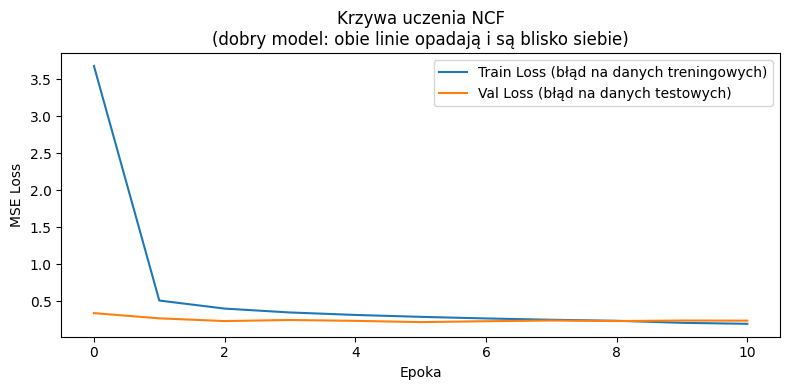

In [11]:
# ── Krzywa uczenia ────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(historia_train, label="Train Loss (błąd na danych treningowych)")
plt.plot(historia_val,   label="Val Loss (błąd na danych testowych)")
plt.xlabel("Epoka")
plt.ylabel("MSE Loss")
plt.title("Krzywa uczenia NCF\n(dobry model: obie linie opadają i są blisko siebie)")
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
# ── Ewaluacja NCF ─────────────────────────────────────────────────────────────
wyniki_ncf, pred_ncf = ewaluuj_ncf(
    model_ncf, test_loader, test_df_clean, test_df_clean["Rating"].values,
    user2id, wine2id, device, nazwa="NCF"
)
print("Wyniki NCF:", wyniki_ncf)


Wyniki NCF: {'Model': 'NCF', 'RMSE': 0.4710486635613319, 'MAE': 0.35484686493873596, 'R2': 0.3309638500213623, 'Precision@5': 0.7666229794670162, 'Recall@5': 0.8250205165849985, 'NDCG@5': 0.9795320537750343, 'Precision@10': 0.7468926553672317, 'Recall@10': 0.9212310913395161, 'NDCG@10': 0.9832694989586035, 'Coverage': 0.971}


## 10. Modele bazowe – XGBoost i Random Forest na surowych indeksach

Te modele traktują `user_idx` i `wine_idx` jako zwykłe cechy liczbowe.
To **słabe podejście** – indeksy są arbitralne (user 1 i user 2 nie są „blisko"),
ale służy jako punkt odniesienia (baseline).

> **Baseline** to najprostszy model, który chcemy pokonać.


In [13]:
# Cechy: para (user_idx, wine_idx) → predykcja oceny
X_train_raw = train_df[["user_idx", "wine_idx"]].values
X_test_raw  = test_df_clean[["user_idx", "wine_idx"]].values
y_train_raw = train_df["Rating"].values
y_test_raw  = test_df_clean["Rating"].values

# ── XGBoost Raw ───────────────────────────────────────────────────────────────
print("Trening XGBoost Raw...")
model_xgb_raw = xgb.XGBRegressor(
    n_estimators=100,      # liczba drzew
    max_depth=6,           # max głębokość każdego drzewa
    learning_rate=0.1,     # krok uczenia
    tree_method="hist",    # szybki algorytm histogramowy
    device="cuda" if torch.cuda.is_available() else "cpu",
    objective="reg:squarederror",
    verbosity=0
)
model_xgb_raw.fit(X_train_raw, y_train_raw)

wyniki_xgb_raw, _ = ewaluuj_sklearn(
    model_xgb_raw, X_test_raw, test_df_clean, y_test_raw,
    fn_coverage=lambda: coverage_raw(model_xgb_raw, user2id, wine2id),
    nazwa="XGBoost Raw"
)
print("XGBoost Raw:", wyniki_xgb_raw)

# ── Random Forest Raw ─────────────────────────────────────────────────────────
print("\nTrening Random Forest Raw...")
model_rf_raw = RandomForestRegressor(
    n_estimators=50,   # liczba drzew w lesie
    max_depth=10,      # max głębokość drzewa
    n_jobs=-1,         # używaj wszystkich rdzeni CPU
    random_state=42
)
model_rf_raw.fit(X_train_raw, y_train_raw)

wyniki_rf_raw, _ = ewaluuj_sklearn(
    model_rf_raw, X_test_raw, test_df_clean, y_test_raw,
    fn_coverage=lambda: coverage_raw(model_rf_raw, user2id, wine2id),
    nazwa="Random Forest Raw"
)
print("Random Forest Raw:", wyniki_rf_raw)


Trening XGBoost Raw...
XGBoost Raw: {'Model': 'XGBoost Raw', 'RMSE': 0.520777117257944, 'MAE': 0.400881704125844, 'R2': 0.18224758838116906, 'Precision@5': 0.7452162516382701, 'Recall@5': 0.8015374192978383, 'NDCG@5': 0.9720115968793721, 'Precision@10': 0.7282485875706214, 'Recall@10': 0.899619273184433, 'NDCG@10': 0.9769976283632369, 'Coverage': 0.993}

Trening Random Forest Raw...
Random Forest Raw: {'Model': 'Random Forest Raw', 'RMSE': 0.5235191205088413, 'MAE': 0.40591772526864467, 'R2': 0.173613634474153, 'Precision@5': 0.7427697684578418, 'Recall@5': 0.7983073118246116, 'NDCG@5': 0.9714912271450798, 'Precision@10': 0.7214689265536723, 'Recall@10': 0.8902274644282173, 'NDCG@10': 0.9764473303575053, 'Coverage': 0.991}


## 11. Ekstrakcja embeddingów z NCF

Zamiast trenować XGBoost/RF na surowych indeksach (user=5, wine=42),
dajemy im **embeddingi z NCF** – wektory 50D, które zawierają informację
o preferencjach użytkownika i charakterze wina.

To jest **transfer learning**: wiedza z sieci neuronowej przekazana do drzew.

```
NCF embedding użytkownika: [0.12, -0.34, 0.78, ...] (50 liczb)
NCF embedding wina:        [0.55,  0.11, -0.22, ...] (50 liczb)
Cechy dla XGB/RF:          [0.12, -0.34, ..., 0.55, 0.11, ...] (100 liczb)
```


In [14]:
def ekstrahuj_embeddingi(model, loader, device):
    """
    Dla każdego rekordu w loaderze pobiera embeddingi użytkownika i wina
    i skleja je w jeden wektor cech.
    Wynik: macierz (n_próbek × 100), wektor etykiet (n_próbek,)
    """
    model.eval()
    cechy_lista, etykiety_lista = [], []
    with torch.no_grad():
        for u, w, r in loader:
            u, w = u.to(device), w.to(device)
            # Concatenacja embeddingów: [user_emb, wine_emb]
            emb = torch.cat([model.user_embedding(u),
                              model.wine_embedding(w)], dim=1).cpu().numpy()
            cechy_lista.append(emb)
            etykiety_lista.append(r.numpy())
    return np.concatenate(cechy_lista), np.concatenate(etykiety_lista)


print("Ekstrakcja embeddingów...")
X_train_emb, y_train_emb = ekstrahuj_embeddingi(model_ncf, train_loader, device)
X_test_emb,  y_test_emb  = ekstrahuj_embeddingi(model_ncf, test_loader,  device)
print(f"Kształt cech treningowych : {X_train_emb.shape}")
print(f"Kształt cech testowych    : {X_test_emb.shape}")
print("(kolumny = 50 wymiarów embeddingu użytkownika + 50 wymiarów wina)")


Ekstrakcja embeddingów...
Kształt cech treningowych : (120000, 100)
Kształt cech testowych    : (28200, 100)
(kolumny = 50 wymiarów embeddingu użytkownika + 50 wymiarów wina)


## 12. Hybryda: XGBoost + NCF Embeddings

Trenujemy XGBoost na embeddingach z NCF.
Oczekujemy lepszych wyników niż XGBoost Raw, bo embeddingi zawierają
więcej informacji semantycznej.


In [15]:
print("Trening XGBoost + NCF Embeddings...")
model_xgb_emb = xgb.XGBRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=6,
    tree_method="hist",
    device="cuda" if torch.cuda.is_available() else "cpu",
    objective="reg:squarederror", verbosity=0
)
model_xgb_emb.fit(X_train_emb, y_train_emb)

wyniki_xgb_emb, _ = ewaluuj_sklearn(
    model_xgb_emb, X_test_emb, test_df_clean, y_test_emb,
    fn_coverage=lambda: coverage_emb(model_xgb_emb, model_ncf, user2id, wine2id, device),
    nazwa="XGBoost + NCF Emb"
)
print("XGBoost + NCF Emb:", wyniki_xgb_emb)

# Globalny ranking
print("\nLiczę globalny ranking XGBoost + NCF Emb (może chwilę potrwać)...")
global_xgb_emb = globalny_ranking_emb(
    model_xgb_emb, model_ncf, test_df_clean, y_test_emb,
    user2id, wine2id, device, k=10, n_uzytk=150
)
print("Globalny ranking XGBoost+Emb:", global_xgb_emb)


Trening XGBoost + NCF Embeddings...
XGBoost + NCF Emb: {'Model': 'XGBoost + NCF Emb', 'RMSE': 0.4624260127969521, 'MAE': 0.34675490856170654, 'R2': 0.355233371257782, 'Precision@5': 0.7704674530362603, 'Recall@5': 0.8289297141540912, 'NDCG@5': 0.981299263595647, 'Precision@10': 0.7466101694915253, 'Recall@10': 0.9200815165280323, 'NDCG@10': 0.9844127866068851, 'Coverage': 0.996}

Liczę globalny ranking XGBoost + NCF Emb (może chwilę potrwać)...
Globalny ranking XGBoost+Emb: {'Global_Precision@10': 0.013432835820895524, 'Global_Recall@10': 0.0435471452262497, 'Global_NDCG@10': 0.028164560520257582, 'N_uzytkownikow_global': 134}


## 13. Hybryda: Random Forest + NCF Embeddings


In [16]:
print("Trening Random Forest + NCF Embeddings...")
model_rf_emb = RandomForestRegressor(
    n_estimators=100, max_depth=15, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)
model_rf_emb.fit(X_train_emb, y_train_emb)

wyniki_rf_emb, _ = ewaluuj_sklearn(
    model_rf_emb, X_test_emb, test_df_clean, y_test_emb,
    fn_coverage=lambda: coverage_emb(model_rf_emb, model_ncf, user2id, wine2id, device),
    nazwa="Random Forest + NCF Emb"
)
print("Random Forest + NCF Emb:", wyniki_rf_emb)

print("\nLiczę globalny ranking RF + NCF Emb...")
global_rf_emb = globalny_ranking_emb(
    model_rf_emb, model_ncf, test_df_clean, y_test_emb,
    user2id, wine2id, device, k=10, n_uzytk=150
)
print("Globalny ranking RF+Emb:", global_rf_emb)


Trening Random Forest + NCF Embeddings...
Random Forest + NCF Emb: {'Model': 'Random Forest + NCF Emb', 'RMSE': 0.4580430967862693, 'MAE': 0.34305894376414653, 'R2': 0.3673977510547207, 'Precision@5': 0.7697684578418523, 'Recall@5': 0.8284403401719257, 'NDCG@5': 0.9809406015744333, 'Precision@10': 0.746045197740113, 'Recall@10': 0.9178747176441592, 'NDCG@10': 0.983991089259503, 'Coverage': 0.999}

Liczę globalny ranking RF + NCF Emb...
Globalny ranking RF+Emb: {'Global_Precision@10': 0.012686567164179105, 'Global_Recall@10': 0.03166903577351338, 'Global_NDCG@10': 0.024636839384754063, 'N_uzytkownikow_global': 134}


## 14. Podsumowanie wyników wszystkich modeli


In [17]:
wszystkie_wyniki = [
    wyniki_xgb_raw,
    wyniki_rf_raw,
    wyniki_ncf,
    wyniki_xgb_emb,
    wyniki_rf_emb,
    wyniki_rp3_lokalny,
    wyniki_rp3_globalny,
]

KOLUMNY = [
    "Model",
    "RMSE", "MAE", "R2",
    "Precision@5", "Recall@5", "NDCG@5",
    "Precision@10", "Recall@10", "NDCG@10",
    "Coverage",
]

tabela = pd.DataFrame(wszystkie_wyniki, columns=KOLUMNY)
kolumny_num = tabela.select_dtypes(include="number").columns
tabela[kolumny_num] = tabela[kolumny_num].round(4)

print("=" * 80)
print("PORÓWNANIE MODELI (posortowane według NDCG@10 – im wyżej, tym lepiej)")
print("=" * 80)
display(tabela.sort_values("NDCG@10", ascending=False, na_position="last"))

print("""
Legenda kolumn:
  RMSE    – błąd predykcji oceny (niższy = lepiej); NaN dla RP3β bo nie przewiduje ocen 1-5
  MAE     – średni błąd bezwzględny oceny
  R²      – współczynnik determinacji (1.0 = idealny model)
  P@k     – Precision@k: ile z top-k rekomendacji ma ocenę >= 4.0
  R@k     – Recall@k: ile dobrych win trafiło do top-k
  NDCG@k  – jakość rankingu z gradowaną trafnością (1.0 = idealny ranking)
  Coverage – % katalogu win zarekomendowanych choć raz (100 losowych użytkowników)
  lokalny  – ranking tylko wśród win ocenionych przez użytkownika w teście
  globalny – ranking wśród WSZYSTKICH win w katalogu (realistyczna symulacja)
""")


PORÓWNANIE MODELI (posortowane według NDCG@10 – im wyżej, tym lepiej)


,Model,RMSE,MAE,R2,Precision@5,Recall@5,NDCG@5,Precision@10,Recall@10,NDCG@10,Coverage
3,XGBoost + NCF Emb,0.4624,0.3468,0.3552,0.7705,0.8289,0.9813,0.7466,0.9201,0.9844,0.996
4,Random Forest + NCF Emb,0.4580,0.3431,0.3674,0.7698,0.8284,0.9809,0.7460,0.9179,0.9840,0.999
2,NCF,0.4710,0.3548,0.3310,0.7666,0.8250,0.9795,0.7469,0.9212,0.9833,0.971
0,XGBoost Raw,0.5208,0.4009,0.1822,0.7452,0.8015,0.9720,0.7282,0.8996,0.9770,0.993
1,Random Forest Raw,0.5235,0.4059,0.1736,0.7428,0.7983,0.9715,0.7215,0.8902,0.9764,0.991
5,RP3β (lokalny),NaN,NaN,NaN,0.7134,0.7693,0.9547,0.7008,0.8697,0.9571,0.129
6,RP3β (globalny),NaN,NaN,NaN,0.0719,0.1549,0.0039,0.0637,0.2661,0.0224,0.129



Legenda kolumn:
  RMSE    – błąd predykcji oceny (niższy = lepiej); NaN dla RP3β bo nie przewiduje ocen 1-5
  MAE     – średni błąd bezwzględny oceny
  R²      – współczynnik determinacji (1.0 = idealny model)
  P@k     – Precision@k: ile z top-k rekomendacji ma ocenę >= 4.0
  R@k     – Recall@k: ile dobrych win trafiło do top-k
  NDCG@k  – jakość rankingu z gradowaną trafnością (1.0 = idealny ranking)
  Coverage – % katalogu win zarekomendowanych choć raz (100 losowych użytkowników)
  lokalny  – ranking tylko wśród win ocenionych przez użytkownika w teście
  globalny – ranking wśród WSZYSTKICH win w katalogu (realistyczna symulacja)



## 15. Wykres porównawczy: RMSE vs NDCG@10


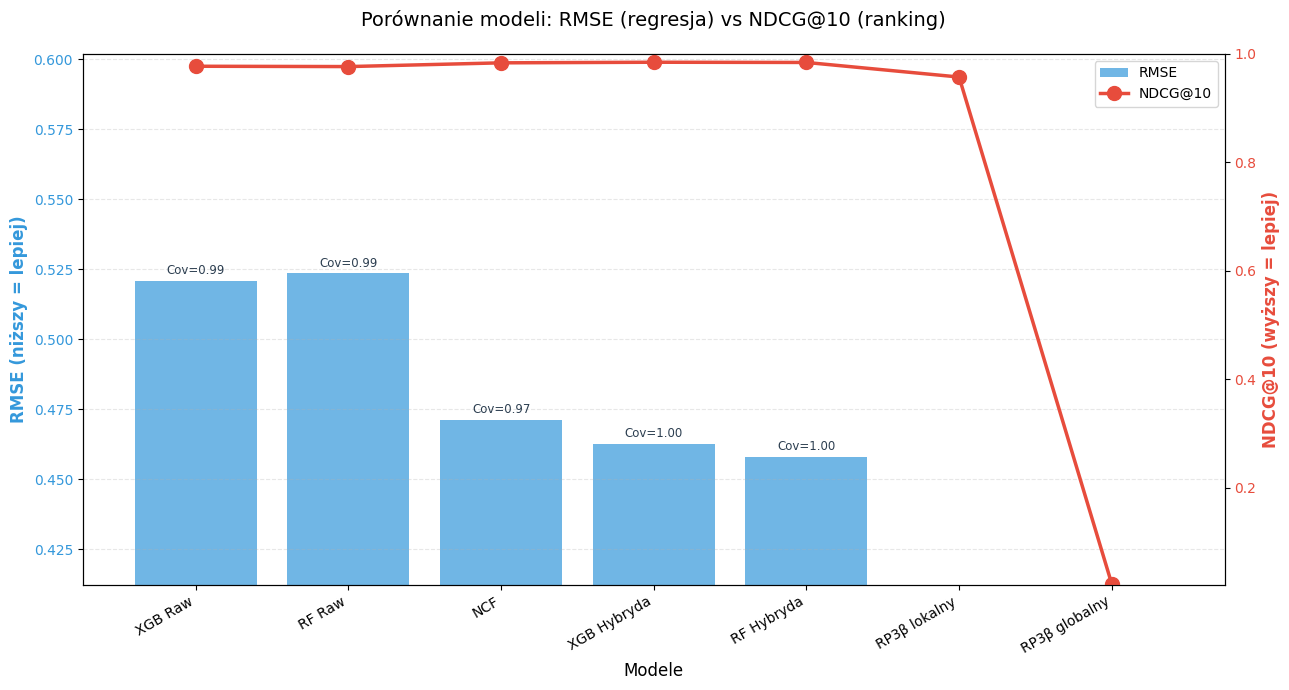

In [18]:
# Skrócone nazwy na wykres
skrocone_nazwy = {
    "XGBoost Raw":             "XGB Raw",
    "Random Forest Raw":       "RF Raw",
    "NCF":                     "NCF",
    "XGBoost + NCF Emb":       "XGB Hybryda",
    "Random Forest + NCF Emb": "RF Hybryda",
    "RP3β (lokalny)":          "RP3β lokalny",
    "RP3β (globalny)":         "RP3β globalny",
}
tabela["Etykieta"] = tabela["Model"].map(skrocone_nazwy).fillna(tabela["Model"])

fig, ax1 = plt.subplots(figsize=(13, 7))

KOLOR_SLUPKI = "#3498db"
KOLOR_LINIA  = "#e74c3c"

# Słupki RMSE (RP3β nie ma RMSE – pokazujemy 0 z adnotacją)
rmse_wartosci = tabela["RMSE"].fillna(0).values
slupki = ax1.bar(tabela["Etykieta"], rmse_wartosci,
                  color=KOLOR_SLUPKI, alpha=0.7, label="RMSE")
ax1.set_xlabel("Modele", fontsize=12)
ax1.set_ylabel("RMSE (niższy = lepiej)", color=KOLOR_SLUPKI, fontsize=12, fontweight="bold")
ax1.tick_params(axis="y", labelcolor=KOLOR_SLUPKI)

# Dopasowanie osi Y dla RMSE
rmse_bez_nan = tabela["RMSE"].dropna()
if not rmse_bez_nan.empty:
    ax1.set_ylim(rmse_bez_nan.min() * 0.9, rmse_bez_nan.max() * 1.15)

# Linia NDCG@10
ax2 = ax1.twinx()
ax2.plot(tabela["Etykieta"], tabela["NDCG@10"],
         color=KOLOR_LINIA, marker="o", markersize=10,
         linewidth=2.5, label="NDCG@10")
ax2.set_ylabel("NDCG@10 (wyższy = lepiej)", color=KOLOR_LINIA,
               fontsize=12, fontweight="bold")
ax2.tick_params(axis="y", labelcolor=KOLOR_LINIA)
ndcg_bez_nan = tabela["NDCG@10"].dropna()
if not ndcg_bez_nan.empty:
    ax2.set_ylim(ndcg_bez_nan.min() * 0.92, 1.0)

# Adnotacje z coverage
for slupek, wiersz in zip(slupki, tabela.itertuples()):
    cov   = wiersz.Coverage if not pd.isna(wiersz.Coverage) else 0
    label = f"Cov={cov:.2f}"
    if pd.isna(wiersz.RMSE):
        label = f"RMSE=N/A\n{label}"
    ax1.annotate(label,
                 xy=(slupek.get_x() + slupek.get_width() / 2, slupek.get_height()),
                 xytext=(0, 5), textcoords="offset points",
                 ha="center", fontsize=8.5, color="#2c3e50")

plt.title("Porównanie modeli: RMSE (regresja) vs NDCG@10 (ranking)",
          fontsize=14, pad=20)
ax1.grid(axis="y", linestyle="--", alpha=0.3)
plt.setp(ax1.get_xticklabels(), rotation=30, ha="right")

linie1, etykiety1 = ax1.get_legend_handles_labels()
linie2, etykiety2 = ax2.get_legend_handles_labels()
ax1.legend(linie1 + linie2, etykiety1 + etykiety2, loc="upper right")

fig.tight_layout()
plt.show()


## 16. Case Study – rekomendacje dla konkretnego użytkownika

Sprawdzamy jak system działa w praktyce: podajemy ID użytkownika
i otrzymujemy top-5 rekomendacji.


In [19]:
def rekomenduj_dla_uzytkownika(user_id, ncf_model, xgb_model, df_pelny,
                                user2id, wine2id, device,
                                top_n=5, n_kandydatow=1000):
    """
    Generuje top-N rekomendacji dla użytkownika, używając hybrydy NCF + XGBoost.

    Kroki:
    1. Zbieramy historię ocen użytkownika
    2. Filtrujemy wina, których jeszcze nie oceniał
    3. Dla każdego kandydackiego wina obliczamy embeddingi z NCF
    4. XGBoost przewiduje ocenę na podstawie embeddingów
    5. Zwracamy top-N według przewidywanej oceny
    """
    random.seed(42)
    np.random.seed(42)

    # Historia użytkownika
    historia = (df_pelny[df_pelny["UserID"] == user_id]
                .sort_values("Rating", ascending=False)
                .head(10)[["WineID", "Rating", "Date"]])

    # Wina niewidziane przez użytkownika
    widziane     = set(df_pelny[df_pelny["UserID"] == user_id]["WineID"])
    kandydaci    = [w for w in wine2id if w not in widziane]
    if len(kandydaci) > n_kandydatow:
        kandydaci = random.sample(kandydaci, n_kandydatow)

    u_idx     = user2id[user_id]
    w_indeksy = [wine2id[w] for w in kandydaci]

    # Embeddingi dla par (user, wine_kandydat)
    ncf_model.eval()
    with torch.no_grad():
        u_t   = torch.full((len(w_indeksy),), u_idx, dtype=torch.long, device=device)
        w_t   = torch.tensor(w_indeksy, dtype=torch.long, device=device)
        cechy = torch.cat([ncf_model.user_embedding(u_t),
                           ncf_model.wine_embedding(w_t)], dim=1).cpu().numpy()

    # Przewidywane oceny
    pred = xgb_model.predict(cechy)
    rekomendacje = (pd.DataFrame({"WineID": kandydaci, "Przewidywana ocena": pred})
                    .sort_values("Przewidywana ocena", ascending=False)
                    .head(top_n))
    return historia, rekomendacje


przykladowy_user = train_df["UserID"].iloc[50]
historia, rekomendacje = rekomenduj_dla_uzytkownika(
    przykladowy_user, model_ncf, model_xgb_emb, df, user2id, wine2id, device
)

print(f"CASE STUDY: użytkownik {przykladowy_user}")
print("\n▶ Najwyżej ocenione wina w historii użytkownika:")
display(historia)
print("\n▶ Top-5 rekomendacji hybrydowych:")
display(rekomendacje)


CASE STUDY: użytkownik 1197665

▶ Najwyżej ocenione wina w historii użytkownika:


,WineID,Rating,Date
4071,135871,4.5,2014-01-16 20:04:48
131233,113050,4.5,2021-02-17 20:38:42
44348,179084,4.0,2017-04-12 07:30:34
50,136522,4.0,2012-09-09 10:58:31
57215,179044,4.0,2017-12-18 14:58:45
66126,106688,4.0,2018-05-26 15:06:18
124209,112185,4.0,2020-11-02 21:31:51
96648,171001,4.0,2019-09-10 11:10:31
48773,155618,4.0,2017-07-06 11:34:33
33052,101660,4.0,2016-07-31 18:40:54



▶ Top-5 rekomendacji hybrydowych:


,WineID,Przewidywana ocena
112,112084,4.668921
476,144337,4.620619
466,183379,4.579392
17,174184,4.550402
5,111415,4.542974


## 17. Rekomendacje z elementem niespodzianki (Serendipity)

**Problem z czystą trafnością:** modele polecają tylko popularne wina.
Użytkownik dostaje ciągle te same propozycje.

**Serendipity** balansuje między:
- **Trafnością** – model przewiduje że użytkownik polubi wino
- **Nowością** – wino jest mało popularne w katalogu

```
Serendipity = (1 - surprise_factor) × ocena_znormalizowana
            +       surprise_factor  × nowość
```

- `surprise_factor = 0.0` → tylko predykcja (standardowy top-N)
- `surprise_factor = 0.4` → mix (rekomendowany dla większości zastosowań)
- `surprise_factor = 0.8` → dominuje nowość (eksperymenty z odkrywaniem)


In [20]:
def rekomenduj_serendipity(user_id, ncf_model, xgb_model, df_pelny,
                            user2id, wine2id, device,
                            top_n=5, n_kandydatow=50,
                            surprise_factor=0.3):
    """
    Rekomendacje z elementem niespodzianki.

    surprise_factor ∈ [0, 1]:
      0.0 = tylko przewidywana ocena (jak standardowy Top-N)
      1.0 = tylko nowość (anty-popularność)
    """
    # Pobieramy kandydatów z funkcji hybrydowej
    _, kandydaci_df = rekomenduj_dla_uzytkownika(
        user_id, ncf_model, xgb_model, df_pelny,
        user2id, wine2id, device, top_n=n_kandydatow
    )

    # Liczymy popularność każdego wina w danych
    popularnosc_win = df_pelny["WineID"].value_counts()
    max_pop         = popularnosc_win.max()

    kandydaci_df["Popularnosc"] = (kandydaci_df["WineID"]
                                   .map(popularnosc_win).fillna(0) / max_pop)
    kandydaci_df["Nowosc"]      = 1.0 - kandydaci_df["Popularnosc"]

    # Normalizujemy przewidywaną ocenę do [0, 1]
    r_min = kandydaci_df["Przewidywana ocena"].min()
    r_max = kandydaci_df["Przewidywana ocena"].max()
    kandydaci_df["Ocena_norm"] = (
        (kandydaci_df["Przewidywana ocena"] - r_min) / (r_max - r_min + 1e-8)
    )

    # Łączymy oba czynniki
    kandydaci_df["Serendipity"] = (
        (1 - surprise_factor) * kandydaci_df["Ocena_norm"] +
        surprise_factor       * kandydaci_df["Nowosc"]
    )

    return (kandydaci_df
            .sort_values("Serendipity", ascending=False)
            .head(top_n)
            [["WineID", "Przewidywana ocena", "Popularnosc", "Nowosc", "Serendipity"]])


print("─── Serendipity = 0.0  (czysta predykcja – tylko trafność) ───")
display(rekomenduj_serendipity(przykladowy_user, model_ncf, model_xgb_emb, df,
                                user2id, wine2id, device, surprise_factor=0.0))

print("\n─── Serendipity = 0.4  (mix: trafność + nowość) ───")
display(rekomenduj_serendipity(przykladowy_user, model_ncf, model_xgb_emb, df,
                                user2id, wine2id, device, surprise_factor=0.4))

print("\n─── Serendipity = 0.8  (dominuje nowość) ───")
display(rekomenduj_serendipity(przykladowy_user, model_ncf, model_xgb_emb, df,
                                user2id, wine2id, device, surprise_factor=0.8))


─── Serendipity = 0.0  (czysta predykcja – tylko trafność) ───


,WineID,Przewidywana ocena,Popularnosc,Nowosc,Serendipity
112,112084,4.668921,0.135065,0.864935,1.000000
476,144337,4.620619,0.011039,0.988961,0.887953
466,183379,4.579392,0.013636,0.986364,0.792317
17,174184,4.550402,0.420779,0.579221,0.725068
5,111415,4.542974,0.487013,0.512987,0.707837



─── Serendipity = 0.4  (mix: trafność + nowość) ───


,WineID,Przewidywana ocena,Popularnosc,Nowosc,Serendipity
112,112084,4.668921,0.135065,0.864935,0.945974
476,144337,4.620619,0.011039,0.988961,0.928356
466,183379,4.579392,0.013636,0.986364,0.869936
851,181199,4.540736,0.011039,0.988961,0.817172
688,179805,4.539340,0.064286,0.935714,0.793931



─── Serendipity = 0.8  (dominuje nowość) ───


,WineID,Przewidywana ocena,Popularnosc,Nowosc,Serendipity
476,144337,4.620619,0.011039,0.988961,0.968759
466,183379,4.579392,0.013636,0.986364,0.947554
851,181199,4.540736,0.011039,0.988961,0.931698
268,181280,4.511377,0.025974,0.974026,0.906129
625,108976,4.469228,0.005195,0.994805,0.903198
